Created by Angelo Orletti Del Rey for its masters in psychiatry at Unifesp - SP - Brasil

It was based in our groups previeous works in cotical striatal connectivity in INPD data base of fmri

In [1]:
import numpy as np
import os, sys
import bids
import nibabel as nib
from scipy.stats import skew
from scipy.stats import chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf
from nilearn import plotting as nplot
from nilearn import image as nimg
from nilearn.image import resample_to_img
import matplotlib.pyplot as plt
import argparse
import pandas as pd
from statsmodels.genmod.families import NegativeBinomial

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from scipy.linalg import LinAlgError

# Suppress convergence warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")


c:\Users\angel\Documents\masters-uploaded-github\INPD-neuroimage-cape\.venv-CAPE-neuroimag\lib\site-packages\nilearn\__init__.py:67: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


In [2]:
def parse():

        options = argparse.ArgumentParser(description="Run 1st level analysis. Created by ...")
        options.add_argument('-p', '--participants', nargs='+',dest="participants", action='store', type=str, required=False,
                            help='id of subject or list of subjects')
        options.set_defaults(participants=None)
        options.add_argument('-w', '--workdir',dest="workdir", action='store', type=str, required=False,
                            help='the work directory for the project')
        options.set_defaults(workdir=os.environ["ROOTDIR"])
        options.add_argument('-b', '--bidsdir',dest="rawdata", action='store', type=str, required=False,
                            help='the work directory for the project')
        options.set_defaults(rawdata=os.path.join(os.environ["ROOTDIR"],"BIDS"))
        options.add_argument('-d', '--derivatives',dest="derivatives", action='store', type=str, required=True,
                            help='path to fMRIprep directory')
        options.add_argument('-o', '--outputs',dest="output", action='store', type=str, required=True,
                            help='path to fMRIprep directory')
        #print(options.parse_args())

        return options.parse_args()

## CHANGE HERE THE PATH TO YOUR DATA
os.environ["ROOTDIR"] = r'D://'   # seth path
rootdir = os.environ["ROOTDIR"]
if hasattr(sys, "ps1"):
    options = {}
    workdir = os.environ["ROOTDIR"]
    firstleveldir  = os.path.join(workdir,"BIDS","derivatives","first_level_results")
    demographic = os.path.join(workdir,"metadata")
    confounds = os.path.join(workdir,"metadata")
    output = os.path.join(workdir,'sensitivity_analisys_second_level')
    participants = []

else :
    options = parse()
    participants = options.participants
    workdir = options.workdir
    rawdata = options.rawdata
    derivat = options.derivatives
    output  = options.outputs

print('firstlevel: ', firstleveldir)
    
bidslayout = bids.BIDSLayout(firstleveldir, validate = False) #With validate = True it doesn't find any subjects

if not participants:
    participants = bidslayout.get_subjects() #take all subjects
    #participants_sub = ["sub-" + item for item in participants]

seednames = ['DCPutamen',
            'DorsalCaudate',
            'DRPutamen',
            'InfVentralCaudate',
            'SupVentralCaudate',
            'VRPutamen'
            ]

tmap_allsubj = [] #initialize array for tmaps

print("Loading tmaps for all participants...")
for p in participants:
    #print(f"Subject: {p}")
    p = p.replace("sub-", "")

    # for ses in bidslayout.get_sessions(subject=p):
    #     #print(f"Session: {ses}")                
    
    ses = '1'

    for r in bidslayout.get_runs(subject=p, session=ses):
        #print(f"Run: {r}")

        tmap_metadata = {
            'task': 'rest',
            'suffix': 'tstat',
            'extension': '.txt',
            'run': str(r),
            'session': str(ses),
            'subject': 'sub-'+p,
            'space': 'MNI152NLin2009cAsym',
            'seed': 'SeedtoROI'
        }

        # Save each tmap as a nifti file
        filepath = os.path.join(firstleveldir,tmap_metadata["subject"],"ses-"+tmap_metadata['session'],"func")
        filename = tmap_metadata["subject"] + "_" + \
                    "ses-"+tmap_metadata['session'] + "_" + \
                    "task-"+tmap_metadata['task'] + "_" + \
                    "run-"+tmap_metadata['run'] + "_" + \
                    "space-"+tmap_metadata['space'] + "_" + \
                    "seed-"+tmap_metadata['seed'] + "_" + \
                    tmap_metadata["suffix"] + \
                    tmap_metadata["extension"]
        tmap_path = os.path.join(filepath, filename)

        #load the tmaps for each subject and then append to the tmap_allsubj array
        tmap = pd.read_csv(tmap_path, delimiter=' ', header=None, skiprows=1) #also skips the first row
        tmap.columns = seednames
        tmap_allsubj.append(tmap)


firstlevel:  D://BIDS\derivatives\first_level_results
Loading tmaps for all participants...


In [5]:
#load socioeconomic and psichometric data for all subjects
print("Loading socioeconomic and psichometric data for all participants...")
socio_psi=pd.read_csv(os.path.join(demographic,'variaveis_analise_conf_nova-exclusão.tsv'), sep='\t')
#substitute in age colunm , to . for decimals
socio_psi['age'] = socio_psi['age'].replace(',', '.').astype(float)

print('loading the p factor scores')
#this is for matching the subject ids to sub_id format
socidemo_path = os.path.join(rootdir,'fMRI_INPD_sociodemographic')
original_df = pd.read_excel(os.path.join(socidemo_path,'banco_angelo.xlsx'))
print(original_df.columns)
# drop all columns except subjectid and ident
original_df = original_df[['subjectid', 'ident']]
# load p factor scores
p_factor = pd.read_excel(os.path.join(socidemo_path,'HRC_DAWBA_pfactor_w0.xlsx'))
#match the subject ids with the format used in socio_psi
p_factor = pd.merge(p_factor, original_df, on='subjectid', how='left')
p_factor = p_factor.drop(columns=['subjectid'])

print('Merging the two dataframes')
# correct the collumn ident of p_factor to have the format 'sub-XXXXX'
p_factor['ident'] = p_factor['ident'].apply(lambda x: f'sub-{int(x):05d}')
# rename the collumn ident to sub_id
p_factor = p_factor.rename(columns={'ident': 'sub_id'})
# merge the two dataframes on sub_id
socio_psi = pd.merge(socio_psi, p_factor[['sub_id', 'dawba_p']], on='sub_id', how='left')
#drop rows with dawba_p as #NULL!
socio_psi = socio_psi[socio_psi['dawba_p'] != '#NULL!']
# change dawba_p to float
socio_psi['dawba_p'] = socio_psi['dawba_p'].astype(float)


Loading socioeconomic and psichometric data for all participants...
loading the p factor scores
Index(['ident', 'redcap_event_name', 'age', 'selection', 'DQ', 'p_cape1',
       'p_cape1a', 'p_cape1b', 'p_cape1c', 'p_cape1d',
       ...
       'dcodd', 'dccd', 'dcothcd', 'dcother', 'dcpdd', 'dctic', 'dceat',
       'dcpsych', 'dcstere', 'dcototh'],
      dtype='object', length=202)
Merging the two dataframes


In [ ]:
# tmap_allsubj

In [6]:
# organinzing the tmaps. Joining the columns of the tmaps for all subjects. So for each subject
# we have to join the first collunm of the first tmap with the first column of the second tmap and so on
# and then join the second column of the first tmap with the second column of the second tmap and so on
# and so on


print("Organizing tmaps...")
tmap_allsubj = pd.concat(tmap_allsubj, axis=1)
tmap_allsubj_organized = {}

for seed in seednames:
    #drop columns with names different from seednames[i]
    tmap_allsubj_organized[seed] = tmap_allsubj.drop(columns=[col for col in tmap_allsubj.columns if col != seed])

# What do we have now: tmap_allsubj_organized is a dictionary with keys being the seednames and values being
# dataframes with the tmaps for all subjects for that seed. This have dimensions of n_ROIs x n_subjects
# Now we have to transpose it to get the data in the format n_subjects x n_ROIs and then join with the
# socioeconomic and psichometric data
# Also, we have to add the sub_id column to the conectivity data to be able to join with the socioeconomic
# and psichometric data
subs = {'sub_id': []}
for p in participants:
    ses = '1'
    if bidslayout.get_runs(subject=p, session=ses) != []:
        subs['sub_id'].append('sub-'+p)

subs = pd.DataFrame(subs)

# create the collunms names for the data frame of rois
roi_names = [f'roi_{i}' for i in range(101)]

for seed in seednames:
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].transpose()
    tmap_allsubj_organized[seed].columns = roi_names
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].reset_index().join(subs, how='inner')
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].drop(columns=['index'])

# Now we have to join the tmaps with the socioeconomic and psichometric data
print("Joining tmaps with socioeconomic and psichometric data...")

for seed in seednames:
    tmap_allsubj_organized[seed] = pd.merge(tmap_allsubj_organized[seed], socio_psi, on='sub_id', how='inner')
    # tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].drop(columns=['Unnamed: 0'])

print(skew(tmap_allsubj_organized[seednames[0]]['dawba_p']))

# now we run the regression analysis for each seed. The dependent variable is the connectivity and the independent
# variables are the CAPE scores. The socioeconomic variables are used as confund variables
print("Running regression analysis (salience, CEN and default mode network)...")

shaeffer_network = pd.read_csv(os.path.join(demographic, 
    'tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-100Parcels7Networks_dseg.tsv'), delimiter='\t')
shaeffer_network = shaeffer_network[shaeffer_network['name'].str.contains('SalVentAttn|Default|Cont')]

# running the regression analysis for each roi in the salience network
results_networks = {} #, results_default = {}, {}
for seed in seednames:
    results_networks[seed] = {}
    #salience analisys
    for roi in shaeffer_network['index']:

        #building my strign for the fomrula
        model = smf.mixedlm( f'dawba_p ~ roi_{roi} + age  + C(gender)  + abepscore + fd_mean_value', 
                                data=tmap_allsubj_organized[seed], 
                                groups=tmap_allsubj_organized[seed]["colection_site"])
        fit = model.fit()

        # Extract desired values
        results_networks[seed][roi] = {
            'coef': fit.params[f'roi_{roi}'],
            'intercept': fit.params['Intercept'],
            't_value': fit.tvalues[f'roi_{roi}'],
            'p_value': fit.pvalues[f'roi_{roi}'],
            'AIC': fit.aic,
            'BIC': fit.bic,
            # 'deviance': fit.deviance,
            # 'R-squared': fit.rsquared,
            # 'ajusted_R_squared': fit.rsquared_adj,
            # 'degrees_of_freedom': fit.degrees_of_freedom,
            # 'residuals': fit.resid_response,
            # 'mcFadden_R_squared': 1 - fit.deviance / fit.null_deviance,
            # 'log_likelihood': fit.llf
        }

Organizing tmaps...
Joining tmaps with socioeconomic and psichometric data...
0.6662408606858632
Running regression analysis (salience, CEN and default mode network)...


In [12]:
# correcting the p-values in two types: 
# first corret to all p-values in each CAPE score (corr_p_val_within_cape).
# second correct to all p-values in the comparison (corr_p_val_general).

from statsmodels.stats.multitest import multipletests

# correcting p-values for all CAPE scores together
# creating a list with all p-values for all CAPE scores to correct them together
all_p_values = [results_networks[seed][roi]['p_value']
                 for seed in seednames
                 for roi in results_networks[seed].keys()]

print(f"Total number of tests: {len(all_p_values)}")
# print(all_p_values)
# Correct the p-values for all CAPE scores together
corrected_p_values_all = multipletests(all_p_values, method='fdr_bh')[1]
# print(corrected_p_values_all)
# printing the ones that are significant after correcting for all CAPE scores together
print(f'General FDR - All CAPE scores together')
index = 0
for seed in seednames:
    for roi in results_networks[seed].keys():
        results_networks[seed][roi]['corr_p_value_general'] = corrected_p_values_all[index]
        index += 1

        if results_networks[seed][roi]['corr_p_value_general'] <= 0.05:
            print(f"###roi-{roi} -> corr_p_val_general {results_networks[seed][roi]['corr_p_value_general']:.3f} -> Association {(results_networks[seed][roi]['coef']):.3f} -> t-value {results_networks[seed][roi]['t_value']:.3f} -> R2 ajustado {results_networks[seed][roi]['ajusted_R_squared']:.3f} ")

print('---Top 5 associations for each CAPE score without general FDR correction---')
associations = []
for seed in seednames:
    for roi in results_networks[seed].keys():
        associations.append((results_networks[seed][roi]['coef'], seed, roi, results_networks[seed][roi]['p_value'], results_networks[seed][roi]['t_value'], results_networks[seed][roi]['corr_p_value_general']))
# Sort the associations by absolute value of the coefficient and get the top 5
top_associations = sorted(associations, key=lambda x: abs(x[0]), reverse=True)[:5]
print(f"Top 5 associations for dawba-p:")
for assoc in top_associations:
    print(f"### seed-{assoc[1]} roi-{assoc[2]} -> coef {assoc[0]:.3f} -> p_val {assoc[3]:.3f} -> t-value {assoc[4]:.3f}-> corr_p_val_general {assoc[5]:.3f} ")

Total number of tests: 294
General FDR - All CAPE scores together
---Top 5 associations for each CAPE score without general FDR correction---
Top 5 associations for dawba-p:
### seed-DRPutamen roi-27 -> coef -0.059 -> p_val 0.003 -> t-value -2.923-> corr_p_val_general 0.956 
### seed-DorsalCaudate roi-42 -> coef 0.055 -> p_val 0.009 -> t-value 2.599-> corr_p_val_general 0.956 
### seed-DorsalCaudate roi-29 -> coef 0.046 -> p_val 0.022 -> t-value 2.290-> corr_p_val_general 0.956 
### seed-DorsalCaudate roi-28 -> coef 0.045 -> p_val 0.020 -> t-value 2.325-> corr_p_val_general 0.956 
### seed-DorsalCaudate roi-43 -> coef 0.045 -> p_val 0.025 -> t-value 2.237-> corr_p_val_general 0.956 


In [8]:
# exporting the results to a csv file
print("Exporting results to csv files...")

# Merge all regression parameters into a single dataframe grouped by CAPE and seed
all_results = []

for seed in seednames:
    for network in ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']:
        for roi in shaeffer_network[shaeffer_network['name'].str.contains(network)]['index']:
            # Get the result values as a dictionary
            result_dict = results_networks[seed][roi].to_dict('records')[0] if isinstance(results_networks[seed][roi], pd.DataFrame) else results_networks[seed][roi]
            # Add metadata columns to the result dictionary
            result_dict['seed'] = seed
            result_dict['network'] = network
            result_dict['ROI'] = roi
            all_results.append(result_dict)
    

# Create dataframe from list of dictionaries
merged_df = pd.DataFrame(all_results)

# Reorder columns for better readability
column_order = ['seed', 'network', 'ROI', 'coef', 'intercept', 't_value', 'p_value', 
                'corr_p_value_general', 'AIC', 'BIC']
merged_df = merged_df[column_order]

# Save to CSV
merged_df.to_csv(os.path.join(output, 'sensitivity_results_2ndlvl.csv'), index=False)

print(f"Merged dataframe saved to: {os.path.join(output, 'sensitivity_results_2ndlvl.csv')}")
print(f"Shape: {merged_df.shape}")

Exporting results to csv files...
Merged dataframe saved to: D://sensitivity_analisys_second_level\sensitivity_results_2ndlvl.csv
Shape: (294, 10)


In [ ]:
#I need to upload all the .csv files from supplementary_material\\sensitivity_analisys_second_level
# and reorganize them into a single table. The first collumn have to be the file name and then the 
# others keep as they are. I would like to stack one over another, they wolud have all the seed 
# coloumns that they actually have but only with the new one regarding the name of the file. 
# import os
# import pandas as pd
# # Define the directory containing the CSV files
# # root_dir = os.getcwd()
# # # directory = os.path.join(root_dir,'supplementary_materials\\sensitivity_analisys_second_level')
# print(output)

# # Initialize an empty list to store DataFrames
# dataframes = []
# # Loop through all files in the directory
# for filename in os.listdir(output):
#     # the files have to have cape in the name
#     if 'dawba_p' in filename:
#         # Read each CSV file into a DataFrame
#         df = pd.read_csv(os.path.join(output, filename))
#         # Add a new column with the file name (without extension)
#         df['file_name'] = os.path.splitext(filename)[0]
#         # Append the DataFrame to the list
#         dataframes.append(df)
# # Concatenate all DataFrames into a single DataFrame
# combined_df = pd.concat(dataframes, ignore_index=True) 
# # reorganize file_name as first column and drop unnamed column if exists
# cols = combined_df.columns.tolist()
# cols = [cols[-1]] + cols[:-1]
# combined_df = combined_df[cols]
# if 'Unnamed: 0' in combined_df.columns:
#     combined_df = combined_df.drop(columns=['Unnamed: 0'])
# # Save the combined DataFrame to a new xlsx file

# combined_df.to_excel(os.path.join(output, 'combined_sensitivity_analisys_second_level.xlsx'), 
#                    index=False,
#                    engine='openpyxl')

In [ ]:
print(f'maximum ajusted R-squared: {merged_df["ajusted_R_squared"].max()}, present in roi-{merged_df.loc[merged_df["ajusted_R_squared"].idxmax(), "ROI"]} of seed {merged_df.loc[merged_df["ajusted_R_squared"].idxmax(), "seed"]}')
# merged_df

maximum ajusted R-squared: 0.14685469444706445, present in roi-27 of seed DRPutamen


,seed,network,ROI,coef,intercept,t_value,p_value,corr_p_value_general,corr_p_value_intranetwork,AIC,BIC,R-squared,ajusted_R_squared
0,DCPutamen,Vis,1,-4.257076e-03,0.326566,-0.221648,0.824701,0.952720,0.878154,921.399931,953.490068,0.146535,0.131600
1,DCPutamen,Vis,2,-3.654284e-03,0.336994,-0.225865,0.821422,0.952720,0.878154,921.398006,953.488143,0.146540,0.131604
2,DCPutamen,Vis,3,2.122280e-02,0.241464,1.284365,0.199758,0.952720,0.878154,919.770913,951.861050,0.149936,0.135060
3,DCPutamen,Vis,4,-7.620507e-03,0.369730,-0.592775,0.553667,0.952720,0.878154,921.091786,953.181923,0.147180,0.132255
4,DCPutamen,Vis,5,-7.166588e-16,0.328246,-0.243962,0.807386,0.952720,0.878154,921.389146,953.479283,0.146558,0.131623
...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,VRPutamen,Default,96,-1.096744e-02,0.336564,-0.940457,0.347551,0.905949,0.834122,920.548886,952.639024,0.148314,0.133409
596,VRPutamen,Default,97,5.938480e-03,0.310331,0.434347,0.664271,0.983812,0.938252,921.257653,953.347791,0.146833,0.131903
597,VRPutamen,Default,98,1.336969e-02,0.301051,0.797220,0.425796,0.905949,0.929010,920.802282,952.892419,0.147785,0.132871
598,VRPutamen,Default,99,-8.926852e-03,0.338774,-0.497583,0.619051,0.983812,0.938252,921.197576,953.287713,0.146959,0.132030


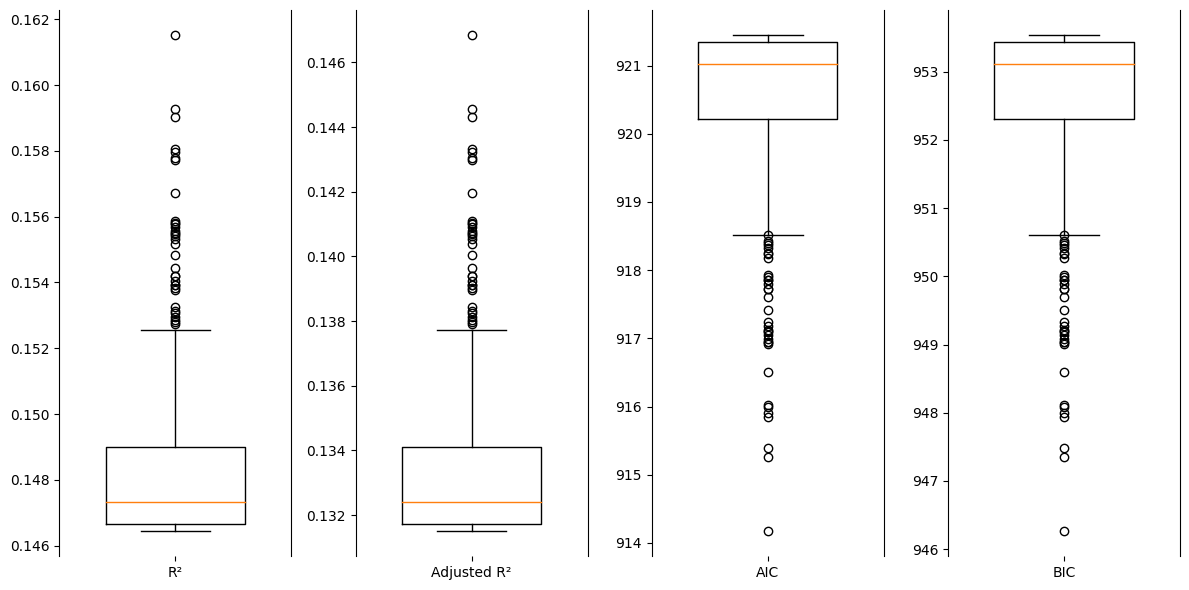

In [ ]:
# plot the distribution of the p factor scores for each seed in the same histogram

metrics = [
    merged_df['R-squared'],
    merged_df['ajusted_R_squared'],
    merged_df['AIC'],
    merged_df['BIC']
]

labels = ['R²', 'Adjusted R²', 'AIC', 'BIC']

plt.figure(figsize=(12, 6))

#create 4 subplots for each metric
for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i+1)
    plt.boxplot(metric, positions=[i], widths=0.6)
    plt.xticks([i], [labels[i]])

    plt.gca().spines['top'].set_visible(False)  # Hide the top spine
    # plt.gca().spines['right'].set_visible(False)  # Hide the right spine
    # plt.gca().spines['left'].set_visible(False)  # Hide the left spine
    plt.gca().spines['bottom'].set_visible(False)  # Hide the bottom spine

plt.tight_layout()

In [ ]:
plt.figure(figsize=(12, 6))
# tmap_allsubj_organized['DRPutamen']
# plt.plot(tmap_allsubj_organized['DRPutamen']['roi_27'], tmap_allsubj_organized['DRPutamen']['dawba_p'], 'o', markersize=3)
#plot the regression line using the coeficient of the regression analysis for roi 27 of seed DRPutamen
# plt.plot(tmap_allsubj_organized['DRPutamen']['roi_27'], merged_df['intercept'].loc[(merged_df['seed'] == 'DRPutamen') & (merged_df['ROI'] == 27)]) + tmap_allsubj_organized['DRPutamen']['roi_27']*merged_df['coef'].loc[(merged_df['seed'] == 'DRPutamen') & (merged_df['ROI'] == 27)])

SyntaxError: invalid syntax (3403123997.py, line 5)